# 06. 피해 지원금 최적화

| 항목 | 내용 |
|---|---|
| 목적 | 같은 예산을 어떻게 나눠야 기상 피해를 가장 잘 메우는지 비교하고, **가설 2(동일 지원은 효과적이지 않다)**를 검증한다 |
| 입력 | `data/processed/damage_unit_summary.parquet` (05 피해 예측: 지역 × 업종 연간 예상 손실·점포당 손실·점포당 매출) |
| 출력 | `data/processed/support_allocation.parquet` (방식별 배분안), 노트북 내 비교표·그림 |
| 브랜치 | `ana-opt` |

> **가설 2**: A·B·C 업체가 같은 피해를 입었어도 매출 규모가 다르면 타격이 다르다(가설 1). 그렇다면 **모든 업체에 같은 금액을 지원하는 것은 효과적이지 않다.**

**진행 순서**
1. 환경 설정·지원 대상
2. 무엇을 '효과'로 볼 것인가 — 평가 지표
3. 배분 방식 5가지
4. 최적화: 모든 점포의 피해율 상한을 최대한 낮추기 (선형계획)
5. 방식별 비교 — 가설 2 검증
6. 예산 규모에 따른 변화
7. 강건성 — 피해 추정 오차·대형유통 포함 여부
8. 기상 유형별 지원 대상 — 가설 3과의 연결
9. 예보 연동 긴급 지원 — 강한 비 하루 시나리오
10. 저장·정리

## 1. 환경 설정·지원 대상

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linprog

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = ROOT / 'data' / 'processed'
load = lambda name: pd.read_parquet(PROC / f'{name}.parquet')

INK, INK2, GRID, SURFACE = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
REGION_COLOR = {'강남구': '#2a78d6', '춘천시': '#eb6834'}
STRAT_COLOR = {'A 균등 지원': '#a3a29c', 'B 피해액 비례': '#86b6ef', 'C 피해액 큰 순': '#2a78d6',
               'D 피해율 높은 순': '#eda100', 'E 최적화(피해율 상한)': '#eb6834'}
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.dpi': 110,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK, 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'lines.linewidth': 2, 'legend.frameon': False,
})
KEYS = ['region', 'industry_group']

summ = load('damage_unit_summary')
units_all = summ.assign(
    L=summ['annual_loss_per_store'].clip(lower=0),          # 점포당 연간 예상 손실(원)
    R=summ['sales_per_store_monthly'] * 12,                  # 점포당 연매출(원)
    n=summ['n_stores'].astype(float))
units_all['rate'] = units_all['L'] / units_all['R'] * 100     # 지원 전 피해율(연매출 대비 %)
units_all['unit'] = units_all['region'] + ' ' + units_all['industry_group']
EXCLUDE = {'대형유통'}   # 백화점·대형마트·쇼핑몰 — 소상공인 지원 취지에 맞지 않아 기본 분석에서 제외
units = units_all[~units_all['industry_group'].isin(EXCLUDE) & (units_all['L'] > 0)].reset_index(drop=True)
TOTAL_LOSS = (units['n'] * units['L']).sum()
print(f"지원 대상: {len(units)}개 단위(지역 × 업종), 점포 {units['n'].sum():,.0f}곳, "
      f"연간 예상 손실 합계 {TOTAL_LOSS / 1e8:,.1f}억원 (신한카드 기준)")
units.sort_values('rate', ascending=False)[['unit', 'n', 'L', 'R', 'rate']].assign(
    L=lambda x: x['L'] / 1e4, R=lambda x: x['R'] / 1e4).rename(
    columns={'n': '점포 수', 'L': '점포당 연간 손실(만원)', 'R': '점포당 연매출(만원)', 'rate': '피해율(%)'}).round(2)

지원 대상: 28개 단위(지역 × 업종), 점포 50,447곳, 연간 예상 손실 합계 1,035.3억원 (신한카드 기준)


,unit,점포 수,점포당 연간 손실(만원),점포당 연매출(만원),피해율(%)
21,춘천시 여가·오락,688.00,518.47,"23,794.06",2.18
17,춘천시 기타소매,"1,362.00",210.09,"12,669.75",1.66
25,춘천시 주점·유흥,610.00,41.97,"2,735.03",1.53
6,강남구 식료품소매,863.00,410.58,"28,513.76",1.44
24,춘천시 의류·잡화,"1,033.00",129.56,"9,387.84",1.38
4,강남구 미용·개인서비스,"3,629.00",138.92,"10,488.92",1.32
16,춘천시 교통·자동차,514.00,960.67,"82,254.57",1.17
19,춘천시 숙박,818.00,23.73,"2,120.01",1.12
20,춘천시 식료품소매,490.00,346.82,"35,524.16",0.98
18,춘천시 미용·개인서비스,"1,537.00",29.60,"3,376.03",0.88


- 금액은 신한카드 결제 기준이라 실제보다 작다. 하지만 손실과 매출이 같은 기준이므로 **피해율(손실 ÷ 매출)**은 비교할 수 있다.
- 그래서 예산도 절대 금액이 아니라 **연간 예상 손실 합계의 몇 %**로 정한다 (기본 25%, 6절에서 10~75%).
- 같은 단위(지역 × 업종) 안의 점포는 '평균 점포' 하나로 보고 같은 손실·매출을 가진다고 가정한다.

## 2. 무엇을 '효과'로 볼 것인가 — 평가 지표

가설 1에서 확인했듯이 업체가 느끼는 타격은 피해 **금액**이 아니라 **피해율(손실 ÷ 매출)**이다. 그래서 지원 효과도 두 가지로 본다.

| 지표 | 정의 | 좋은 방향 |
|---|---|---|
| **보전액** | 실제 손실을 메운 금액 = Σ 점포 수 × min(지원금, 손실) | 클수록 |
| **낭비** | 손실보다 많이 준 금액 = Σ 점포 수 × max(0, 지원금 − 손실) | 작을수록 |
| **평균 피해율 감소** | 점포 평균 (지원 전 피해율 − 지원 후 피해율), %p | 클수록 |
| **최대 잔여 피해율** | 지원 후에도 가장 크게 남은 피해율 — 가장 힘든 업체의 상태 | 작을수록 |
| **고타격 점포 수** | 지원 후 피해율이 기준(그 시나리오의 지원 전 피해율 상위 25% 경계값)을 넘는 점포 수 | 작을수록 |
| **지니계수** | 지원 후 잔여 피해율이 점포 사이에 얼마나 불균등한가 | 작을수록 |

In [2]:
def high_cut(u):
    # 고타격 기준 = 지원 전 피해율의 점포 가중 75백분위 (시나리오마다 계산).
    return np.percentile(np.repeat(u['rate'].values, u['n'].astype(int).values), 75)

HIGH_CUT = high_cut(units)
print(f'고타격 기준(연간): 피해율 {HIGH_CUT:.2f}% 이상 (지원 전 점포 피해율 상위 25%)')

def gini(values, weights):
    order = np.argsort(values)
    v, w = np.asarray(values)[order], np.asarray(weights)[order]
    cw = np.cumsum(w) / w.sum()
    cv = np.cumsum(v * w) / (v * w).sum() if (v * w).sum() > 0 else cw
    return 1 - np.sum((cv[1:] + cv[:-1]) * np.diff(cw)) - cv[0] * cw[0]

def evaluate(u, support, name, cut):
    """support: 점포당 지원금(원) 배열."""
    covered = np.minimum(support, u['L'])
    resid = (u['L'] - covered) / u['R'] * 100
    n = u['n'].values
    return {'방식': name, '집행액(억원)': (n * support).sum() / 1e8, '보전액(억원)': (n * covered).sum() / 1e8,
            '낭비(억원)': (n * np.maximum(support - u['L'], 0)).sum() / 1e8,
            '평균 피해율 감소(%p)': np.average(u['rate'] - resid, weights=n),
            '최대 잔여 피해율(%)': resid.max(), '고타격 점포 수': int(n[(resid >= cut).values].sum()),
            '지니계수': gini(resid.values, n), '춘천 배분 비중(%)': (n * support)[(u['region'] == '춘천시').values].sum() / max((n * support).sum(), 1) * 100}

고타격 기준(연간): 피해율 0.86% 이상 (지원 전 점포 피해율 상위 25%)


## 3. 배분 방식 5가지

| 방식 | 규칙 | 현실의 예 |
|---|---|---|
| **A 균등 지원** | 모든 점포에 같은 금액 (예산 ÷ 점포 수) | 일괄 재난지원금 |
| **B 피해액 비례** | 모든 점포의 손실을 **같은 비율**만큼 보전 | 피해액의 일정 % 보상 |
| **C 피해액 큰 순** | 업종 전체 손실 **금액**이 큰 단위부터 손실 전액 보전 | "피해가 큰 곳부터" |
| **D 피해율 높은 순** | **피해율**이 높은 단위부터 손실 전액 보전 | 취약 업종 우선 |
| **E 최적화 (피해율 상한)** | 모든 점포의 지원 후 피해율이 **c% 이하**가 되도록, 예산 안에서 c를 가장 낮게 | 아래 4절 |

B~E는 손실보다 많이 주지 않는다 (점포당 지원금 ≤ 점포당 손실).

In [3]:
def strat_equal(u, B):
    return np.full(len(u), B / u['n'].sum())

def strat_proportional(u, B):
    return u['L'].values * min(1.0, B / (u['n'] * u['L']).sum())

def strat_greedy(u, B, key):
    s, left = np.zeros(len(u)), B
    for i in u[key].sort_values(ascending=False).index:
        need = u.loc[i, 'n'] * u.loc[i, 'L']
        give = min(need, left)
        s[i] = give / u.loc[i, 'n']
        left -= give
        if left <= 0:
            break
    return s

def total_loss_amount(u):
    return u['n'] * u['L']

## 4. 최적화: 모든 점포의 피해율 상한을 최대한 낮추기

가장 타격이 큰 업체부터 구제하되, 한 업체에 과하게 몰리지 않게 하는 기준으로 **최대-최소(min-max) 문제**를 푼다.

$$\min_{x,\,c} \; c \quad \text{s.t.} \quad \frac{L_u - x_u}{R_u} \le c \;\; (\forall u), \qquad \sum_u n_u x_u \le B, \qquad 0 \le x_u \le L_u$$

- $x_u$: 단위 $u$ 점포 하나에 주는 지원금, $L_u$: 점포당 손실, $R_u$: 점포당 매출, $n_u$: 점포 수, $B$: 예산
- 해석: **지원 후 모든 점포의 피해율이 c% 이하**가 되게 하는 가장 작은 c를 찾는다. 피해율이 c보다 낮은 업체는 지원하지 않고, 높은 업체는 c까지 낮춰 준다 ('물 채우기' 형태).
- 선형계획(`scipy.optimize.linprog`, HiGHS)으로 풀고, 같은 해를 이분 탐색으로도 구해 서로 맞는지 확인한다.

In [4]:
def strat_optimal(u, B):
    # 금액은 만원, c는 % 단위로 맞춰 푼다 (원 단위 그대로면 계수가 1e-9 수준이라 수치 오차가 생김).
    m = len(u)
    L, R, Bm = u['L'].values / 1e4, u['R'].values / 1e4, B / 1e4
    cost = np.r_[np.zeros(m), 1.0]                       # 변수: x_1..x_m(만원), c(%) → c 최소화
    A, b = [], []
    for i in range(m):                                   # 100(L_i − x_i)/R_i ≤ c
        row = np.zeros(m + 1); row[i] = -100 / R[i]; row[-1] = -1
        A.append(row); b.append(-100 * L[i] / R[i])
    A.append(np.r_[u['n'].values, 0.0]); b.append(Bm)   # Σ n_i x_i ≤ B
    bounds = [(0, L[i]) for i in range(m)] + [(0, None)]
    res = linprog(cost, A_ub=np.array(A), b_ub=b, bounds=bounds, method='highs')
    assert res.success, res.message
    return res.x[:m] * 1e4, res.x[-1]

def strat_waterfill(u, B):
    lo, hi = 0.0, (u['L'] / u['R']).max()
    for _ in range(100):
        c = (lo + hi) / 2
        need = (u['n'] * np.maximum(0, u['L'] - c * u['R'])).sum()
        lo, hi = (c, hi) if need > B else (lo, c)
    return np.maximum(0, u['L'] - hi * u['R']).values, hi * 100

B = 0.25 * TOTAL_LOSS
x_lp, c_lp = strat_optimal(units, B)
x_wf, c_wf = strat_waterfill(units, B)
print(f'예산 = 연간 손실의 25% ({B / 1e8:,.1f}억원)')
print(f'선형계획 해: 피해율 상한 c = {c_lp:.3f}% | 이분 탐색 해: {c_wf:.3f}% | 지원금 최대 차이 {np.abs(x_lp - x_wf).max():,.0f}원')

예산 = 연간 손실의 25% (258.8억원)
선형계획 해: 피해율 상한 c = 0.529% | 이분 탐색 해: 0.529% | 지원금 최대 차이 0원


## 5. 방식별 비교 — 가설 2 검증

In [5]:
def run_all(u, B, cut=None):
    cut = high_cut(u) if cut is None else cut
    plans = {
        'A 균등 지원': strat_equal(u, B),
        'B 피해액 비례': strat_proportional(u, B),
        'C 피해액 큰 순': strat_greedy(u.assign(total=total_loss_amount(u)), B, 'total'),
        'D 피해율 높은 순': strat_greedy(u, B, 'rate'),
        'E 최적화(피해율 상한)': strat_optimal(u, B)[0],
    }
    return plans, pd.DataFrame([evaluate(u, s, k, cut) for k, s in plans.items()]).set_index('방식')

plans, res = run_all(units, B)
res.round(2)

,집행액(억원),보전액(억원),낭비(억원),평균 피해율 감소(%p),최대 잔여 피해율(%),고타격 점포 수,지니계수,춘천 배분 비중(%)
방식,,,,,,,,
A 균등 지원,258.83,229.80,29.03,0.25,1.96,3427,0.49,28.78
B 피해액 비례,258.83,258.83,0.00,0.17,1.63,8699,0.35,22.54
C 피해액 큰 순,258.83,258.83,0.00,0.11,2.18,15043,0.49,0.00
D 피해율 높은 순,258.83,258.83,0.00,0.32,0.83,0,0.43,59.15
E 최적화(피해율 상한),258.83,258.83,0.00,0.24,0.53,0,0.16,41.43


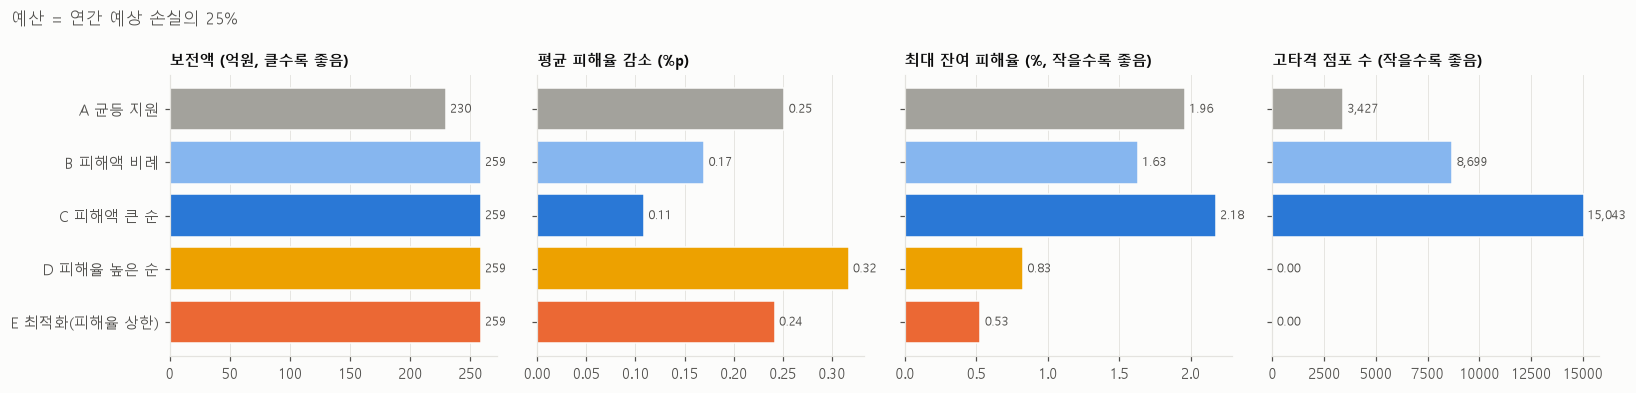

In [6]:
metrics = [('보전액(억원)', '보전액 (억원, 클수록 좋음)'), ('평균 피해율 감소(%p)', '평균 피해율 감소 (%p)'),
           ('최대 잔여 피해율(%)', '최대 잔여 피해율 (%, 작을수록 좋음)'), ('고타격 점포 수', '고타격 점포 수 (작을수록 좋음)')]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (col, title) in zip(axes, metrics):
    v = res[col]
    ax.barh(range(len(v)), v.values, color=[STRAT_COLOR[k] for k in v.index], edgecolor=SURFACE)
    ax.set_yticks(range(len(v)), v.index if ax is axes[0] else [''] * len(v))
    ax.invert_yaxis()
    for i, val in enumerate(v.values):
        ax.text(val, i, f' {val:,.2f}' if val < 100 else f' {val:,.0f}', va='center', fontsize=8, color=INK2)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', visible=False)
fig.suptitle('예산 = 연간 예상 손실의 25%', x=0.01, ha='left', fontsize=11, color=INK2)
fig.tight_layout()

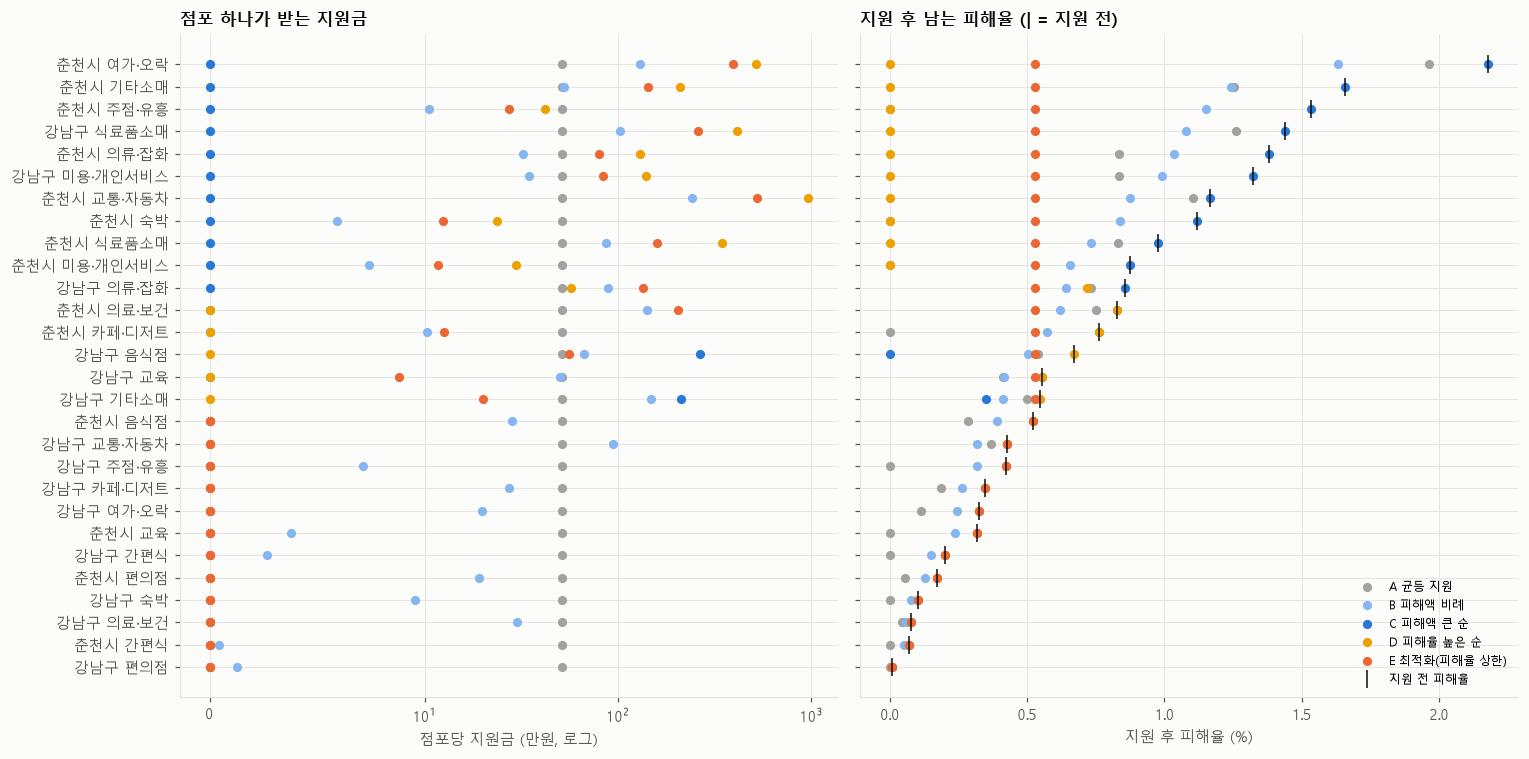

In [7]:
# 점포 하나가 받는 지원금과 지원 후 피해율 — 방식별
detail = []
for k, s in plans.items():
    d = units[['unit', 'region', 'n', 'L', 'R', 'rate']].copy()
    d['방식'] = k
    d['점포당 지원금(만원)'] = s / 1e4
    d['지원 후 피해율(%)'] = (d['L'] - np.minimum(s, d['L'])) / d['R'] * 100
    detail.append(d)
detail = pd.concat(detail)
order = units.sort_values('rate')['unit']
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
y = np.arange(len(order))
for k in plans:
    d = detail[detail['방식'] == k].set_index('unit').loc[order]
    axes[0].plot(d['점포당 지원금(만원)'], y, 'o', ms=5, color=STRAT_COLOR[k], label=k)
    axes[1].plot(d['지원 후 피해율(%)'], y, 'o', ms=5, color=STRAT_COLOR[k], label=k)
pre = units.set_index('unit').loc[order, 'rate']
axes[1].plot(pre, y, '|', ms=12, color=INK, label='지원 전 피해율')
axes[0].set_xscale('symlog', linthresh=10)
axes[0].set_yticks(y, order); axes[0].set_xlabel('점포당 지원금 (만원, 로그)')
axes[1].set_xlabel('지원 후 피해율 (%)')
axes[0].set_title('점포 하나가 받는 지원금', fontsize=11); axes[1].set_title('지원 후 남는 피해율 (| = 지원 전)', fontsize=11)
axes[1].legend(loc='lower right', fontsize=8)
fig.tight_layout()

**해석 — 가설 2 검증 (예산 = 연간 손실의 25%)**
- **A 균등 지원**: 모든 점포에 같은 금액을 주면 손실이 작은 업종(편의점·간편식 등)에는 손실보다 많이 주게 되어 **29억원(예산의 11%)이 낭비**된다. 그런데도 가장 힘든 업체의 피해율은 1.96%로 거의 줄지 않고, 고타격 점포가 3,427곳 남는다.
- **C 피해액 큰 순**: 업종 전체 손실 금액이 큰 강남 음식점·기타소매 등에 예산이 몰리고 **춘천에는 한 푼도 가지 않는다.** 피해율이 가장 높은 춘천 여가·오락(2.18%)이 그대로 남아 최대 잔여 피해율이 가장 나쁘다.
- **B 피해액 비례**: 낭비는 없지만 모든 업체를 같은 비율로 메우므로, 피해율이 높은 업체는 여전히 높다 (고타격 8,699곳).
- **D 피해율 높은 순**: 고타격 점포는 없앴지만, 상위 업종에 손실 전액을 주느라 최대 잔여 피해율이 0.83%에 머문다.
- **E 최적화**: 모든 점포의 피해율을 **0.53% 이하**로 낮춘다. 고타격 점포 0곳, 낭비 0원, 잔여 피해율의 불균등(지니계수 0.16)도 가장 작다. 평균 피해율 감소는 D보다 조금 작지만(0.24 vs 0.32%p), **가장 힘든 업체를 가장 잘 구제**한다.
- → **가설 2 지지**: 같은 예산이라도 **동일 금액 지원은 낭비가 생기고 가장 타격이 큰 업체를 구제하지 못한다.** 업체의 매출 규모를 반영한 **피해율 기준 배분**이 효과적이다.

## 6. 예산 규모에 따른 변화

In [8]:
rows = []
for share in [0.10, 0.25, 0.50, 0.75]:
    _, r = run_all(units, share * TOTAL_LOSS)
    rows.append(r.assign(예산=f'손실의 {share:.0%}'))
budget_cmp = pd.concat(rows).reset_index()
piv = budget_cmp.pivot(index='방식', columns='예산', values=['최대 잔여 피해율(%)', '고타격 점포 수', '낭비(억원)'])
piv.reindex(columns=['손실의 10%', '손실의 25%', '손실의 50%', '손실의 75%'], level=1).round(2)

최대 잔여 피해율(%)                          고타격 점포 수                               낭비(억원)                        
예산                 손실의 10% 손실의 25% 손실의 50% 손실의 75%   손실의 10%   손실의 25%   손실의 50%  손실의 75% 손실의 10% 손실의 25% 손실의 50% 손실의 75%
방식                                                                                                                       
A 균등 지원               2.09    1.96    1.75    1.53  8,579.00  3,427.00  2,065.00 2,065.00    4.89   29.03   85.56  192.90
B 피해액 비례              1.96    1.63    1.09    0.54 10,007.00  8,699.00    688.00     0.00    0.00    0.00    0.00    0.00
C 피해액 큰 순             2.18    2.18    2.18    2.18 15,043.00 15,043.00 11,544.00 7,401.00    0.00    0.00    0.00    0.00
D 피해율 높은 순            1.32    0.83    0.55    0.52 11,520.00      0.00      0.00     0.00    0.00    0.00    0.00    0.00
E 최적화(피해율 상한)         0.82    0.53    0.33    0.15      0.00      0.00      0.00     0.00    0.00    0.00    0.00    0.00

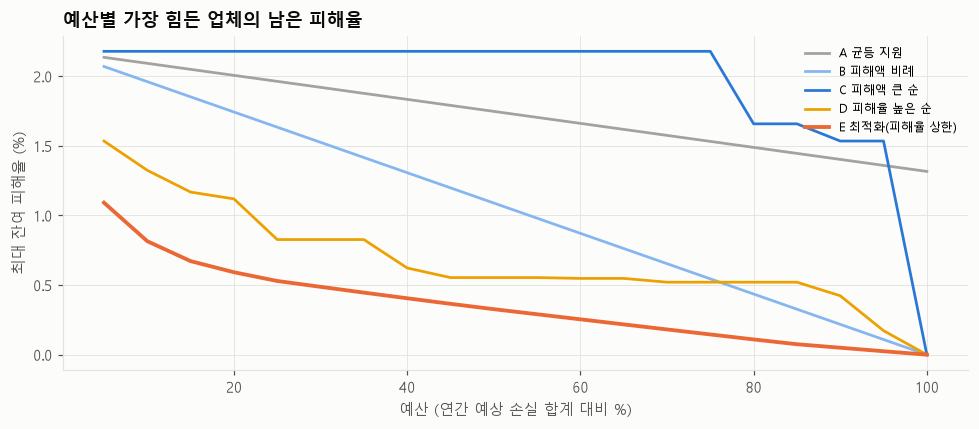

In [9]:
shares = np.linspace(0.05, 1.0, 20)
curve = []
for sh in shares:
    _, r = run_all(units, sh * TOTAL_LOSS)
    curve.append(r['최대 잔여 피해율(%)'].rename(sh))
curve = pd.concat(curve, axis=1).T
fig, ax = plt.subplots(figsize=(9, 4))
for k in curve.columns:
    ax.plot(curve.index * 100, curve[k], color=STRAT_COLOR[k], label=k, lw=2.5 if k.startswith('E') else 1.8)
ax.set_xlabel('예산 (연간 예상 손실 합계 대비 %)'); ax.set_ylabel('최대 잔여 피해율 (%)')
ax.set_title('예산별 가장 힘든 업체의 남은 피해율')
ax.legend(fontsize=8)
fig.tight_layout()

**해석**
- 예산이 늘어도 **C 피해액 큰 순은 최대 잔여 피해율이 2.18%에서 전혀 줄지 않는다** (춘천 여가·오락이 계속 순위 밖).
- A 균등 지원은 예산이 커질수록 낭비가 빠르게 늘어난다 (75%일 때 약 193억원).
- E 최적화는 예산이 늘수록 피해율 상한이 꾸준히 내려간다 (10% → 0.82%, 75% → 0.15%). **어떤 예산 규모에서도 최대 잔여 피해율이 가장 낮다.**

## 7. 강건성
### 7-1. 피해 추정 오차가 있어도 결론이 유지되나
피해 예측에는 오차가 있다. 단위별 손실을 무작위로 흔들어(로그정규, 표준편차 0.3 ≈ ±30%) **'예측 손실'로 배분**하고, **'실제 손실'(흔들기 전 값)로 평가**한다. 500번 반복해 E 최적화가 A 균등 지원보다 나은 비율을 본다.

In [10]:
rng = np.random.default_rng(42)
rob = []
for draw in range(500):
    noisy = units.copy()
    noisy['L'] = units['L'] * rng.lognormal(0, 0.3, len(units))
    noisy['rate'] = noisy['L'] / noisy['R'] * 100
    Bd = 0.25 * (noisy['n'] * noisy['L']).sum()
    p, _ = run_all(noisy, Bd)
    for k, s in p.items():
        rob.append({'draw': draw, **evaluate(units, s, k, HIGH_CUT)})   # 실제 손실·실제 기준으로 평가
rob = pd.DataFrame(rob)
summary_rob = rob.groupby('방식')[['보전액(억원)', '최대 잔여 피해율(%)', '고타격 점포 수', '낭비(억원)']].median()
wins = rob.pivot(index='draw', columns='방식', values='최대 잔여 피해율(%)')
print(f"E가 A보다 최대 잔여 피해율이 낮은 비율: {(wins['E 최적화(피해율 상한)'] < wins['A 균등 지원']).mean():.1%}")
hi = rob.pivot(index='draw', columns='방식', values='고타격 점포 수')
print(f"E가 A보다 고타격 점포 수가 적은 비율: {(hi['E 최적화(피해율 상한)'] < hi['A 균등 지원']).mean():.1%}")
summary_rob.round(2)

E가 A보다 최대 잔여 피해율이 낮은 비율: 99.8%
E가 A보다 고타격 점포 수가 적은 비율: 69.2%


,보전액(억원),최대 잔여 피해율(%),고타격 점포 수,낭비(억원)
방식,,,,
A 균등 지원,236.83,1.96,"3,427.00",30.81
B 피해액 비례,267.64,1.63,"8,699.00",0.00
C 피해액 큰 순,224.54,2.18,"15,043.00",41.21
D 피해율 높은 순,228.60,1.29,"5,451.50",38.27
E 최적화(피해율 상한),261.21,1.10,"2,225.00",2.77


### 7-2. 대형유통을 포함하면

In [11]:
u2 = units_all[units_all['L'] > 0].reset_index(drop=True)
_, r2 = run_all(u2, 0.25 * (u2['n'] * u2['L']).sum())
share_big = {k: (u2['n'] * s)[u2['industry_group'] == '대형유통'].sum() / (u2['n'] * s).sum() * 100 for k, s in run_all(u2, 0.25 * (u2['n'] * u2['L']).sum())[0].items()}
r2['대형유통 배분 비중(%)'] = pd.Series(share_big)
r2[['보전액(억원)', '최대 잔여 피해율(%)', '고타격 점포 수', '대형유통 배분 비중(%)']].round(2)

,보전액(억원),최대 잔여 피해율(%),고타격 점포 수,대형유통 배분 비중(%)
방식,,,,
A 균등 지원,380.93,1.81,4286,1.67
B 피해액 비례,448.28,1.63,9151,42.26
C 피해액 큰 순,448.28,2.18,15450,100.00
D 피해율 높은 순,448.28,1.32,10894,74.20
E 최적화(피해율 상한),448.28,0.75,0,72.00


**해석**
- **피해 추정 오차(±30%)가 있어도** E 최적화가 A 균등 지원보다 최대 잔여 피해율이 낮은 경우가 **99.8%**, 고타격 점포 수가 적은 경우가 **69.2%**다. 오차가 있으면 E에도 약간의 낭비(중앙값 약 2.8억원)가 생기지만 A(약 31억원)보다 훨씬 작다.
- **대형유통을 포함하면** E 최적화도 예산의 72%를 대형유통에 준다. 대형유통의 손실률(연매출 대비 약 1.3%)이 높게 추정되기 때문이다. 피해율 기준만으로는 대기업 매장을 걸러내지 못하므로, **지원 자격(소상공인 여부)을 먼저 정하고 그 안에서 피해율로 배분**해야 한다.

## 8. 기상 유형별 지원 대상 — 가설 3과의 연결
연간 손실을 기상 유형별로 나눠, 유형마다 **피해율이 가장 높은 업종**이 누구인지 본다. 유형별 지원 프로그램(호우·폭염·한파·대설)을 따로 운영하면 대상이 어떻게 달라지는지 확인한다.

In [12]:
TYPES = ['강한비', '보통비', '폭염', '한파', '눈']
rows = []
for t in TYPES:
    d = units_all.copy()
    d['loss_t'] = d[f'annual_loss_{t}'].clip(lower=0) / d['n']
    d['rate_t'] = d['loss_t'] / d['R'] * 100
    d = d[(d['rate_t'] > 0) & ~d['industry_group'].isin(EXCLUDE)].sort_values('rate_t', ascending=False).head(5)
    for rank, (_, r) in enumerate(d.iterrows(), 1):
        rows.append({'기상 유형': t, '순위': rank, '단위': r['unit'], '유형별 피해율(%)': r['rate_t']})
by_type = pd.DataFrame(rows)
by_type.pivot(index='순위', columns='기상 유형', values='단위')[TYPES]

기상 유형,강한비,보통비,폭염,한파,눈
순위,,,,,
1,춘천시 여가·오락,춘천시 여가·오락,춘천시 주점·유흥,춘천시 주점·유흥,강남구 미용·개인서비스
2,춘천시 기타소매,강남구 식료품소매,춘천시 교육,춘천시 여가·오락,강남구 식료품소매
3,춘천시 의류·잡화,춘천시 의류·잡화,춘천시 의료·보건,춘천시 의류·잡화,강남구 의류·잡화
4,춘천시 숙박,춘천시 기타소매,강남구 기타소매,춘천시 기타소매,강남구 음식점
5,강남구 식료품소매,춘천시 숙박,춘천시 미용·개인서비스,춘천시 음식점,춘천시 여가·오락


In [13]:
overlap = {t: set(by_type[by_type['기상 유형'] == t]['단위']) for t in TYPES}
mat = pd.DataFrame([[len(overlap[a] & overlap[b]) for b in TYPES] for a in TYPES], index=TYPES, columns=TYPES)
print('기상 유형별 상위 5개 지원 대상의 겹침 수 (대각선 = 5)')
mat

기상 유형별 상위 5개 지원 대상의 겹침 수 (대각선 = 5)


,강한비,보통비,폭염,한파,눈
강한비,5,5,0,3,2
보통비,5,5,0,3,2
폭염,0,0,5,1,0
한파,3,3,1,5,1
눈,2,2,0,1,5


**해석 — 가설 3과의 연결**
- 강한 비·보통 비의 지원 대상 상위 5개는 같다 (춘천 여가·오락·기타소매·의류·잡화·숙박 등 **방문·외출형 업종**).
- **폭염 지원 대상은 비 지원 대상과 하나도 겹치지 않는다** (춘천 주점·유흥·교육·의료·보건, 강남 기타소매 등).
- 한파는 비와 3개, 눈은 2개 겹친다.
- → 기상 유형마다 피해 업종이 다르므로, **하나의 재난지원 명단이 아니라 기상 유형별 대상 목록**을 따로 두어야 한다. 다만 폭염 쪽 피해는 5단계에서 본 것처럼 계절 효과가 섞였을 수 있어 참고용이다.

## 9. 예보 연동 긴급 지원 — 강한 비 하루 시나리오
연간 예산과 별개로, **강한 비(30mm↑) 예보가 나온 날** 하루치 피해를 긴급 지원하는 경우를 본다.
- 점포당 하루 손실 = 강한 비 날 평균 피해 ÷ 점포 수 (05단계), 점포당 하루 매출 = 월매출 ÷ 30.4
- 예산 = 그날 예상 손실의 30%

In [14]:
day = units_all[~units_all['industry_group'].isin(EXCLUDE)].copy()
day['L'] = (day['loss_day_강한비'].clip(lower=0) / day['n']).fillna(0)
day['R'] = day['sales_per_store_monthly'] / 30.4
day = day[day['L'] > 0].reset_index(drop=True)
day['rate'] = day['L'] / day['R'] * 100
rows = []
for region in ['춘천시', '강남구']:
    d = day[day['region'] == region].reset_index(drop=True)
    Bd = 0.30 * (d['n'] * d['L']).sum()
    p, r = run_all(d, Bd)
    rows.append(r.assign(지역=region).reset_index())
    if region == '춘천시':
        chun_plan = d[['industry_group', 'n', 'L', 'R', 'rate']].assign(
            균등_만원=p['A 균등 지원'] / 1e4, 최적화_만원=p['E 최적화(피해율 상한)'] / 1e4)
emerg = pd.concat(rows)
display(emerg.set_index(['지역', '방식'])[['보전액(억원)', '최대 잔여 피해율(%)', '고타격 점포 수', '낭비(억원)']].round(3))
print('춘천 강한 비 하루: 업종별 점포당 지원금 (만원) — 균등 vs 최적화')
chun_plan.sort_values('rate', ascending=False).rename(columns={'n': '점포 수', 'L': '점포당 하루 손실(원)', 'R': '점포당 하루 매출(원)', 'rate': '하루 피해율(%)'}).round(2)

보전액(억원)  최대 잔여 피해율(%)  고타격 점포 수  낭비(억원)
지역  방식                                                    
춘천시 A 균등 지원           1.51         19.52      2050    0.33
    B 피해액 비례          1.84         15.15       688    0.00
    C 피해액 큰 순         1.84         21.64      3901    0.00
    D 피해율 높은 순        1.84         13.48      1851    0.00
    E 최적화(피해율 상한)     1.84          7.55         0    0.00
강남구 A 균등 지원           4.12          9.31       863    0.17
    B 피해액 비례          4.29          7.76       863    0.00
    C 피해액 큰 순         4.29         11.09      5719    0.00
    D 피해율 높은 순        4.29          5.14         0    0.00
    E 최적화(피해율 상한)     4.29          3.84         0    0.00

춘천 강한 비 하루: 업종별 점포당 지원금 (만원) — 균등 vs 최적화


,industry_group,점포 수,점포당 하루 손실(원),점포당 하루 매출(원),하루 피해율(%),균등_만원,최적화_만원
6,여가·오락,688.00,"141,152.07","652,249.49",21.64,1.38,9.19
2,기타소매,"1,362.00","60,865.27","347,306.85",17.52,1.38,3.47
9,의류·잡화,"1,033.00","38,481.43","257,341.98",14.95,1.38,1.91
4,숙박,818.00,"7,206.70","58,114.41",12.40,1.38,0.28
1,교통·자동차,514.00,"239,842.37","2,254,785.48",10.64,1.38,6.97
10,주점·유흥,610.00,"7,954.00","74,973.44",10.61,1.38,0.23
5,식료품소매,490.00,"99,167.52","973,798.32",10.18,1.38,2.57
11,카페·디저트,"1,128.00","12,606.34","147,682.79",8.54,1.38,0.15
3,미용·개인서비스,"1,537.00","6,345.75","92,544.78",6.86,1.38,0.00
8,의료·보건,579.00,"116,513.30","1,879,163.05",6.20,1.38,0.00


**해석 — 예보 연동 긴급 지원**
- 춘천에 강한 비가 오는 하루, 예상 손실의 30%를 지원할 때:
  - **균등 지원**: 모든 점포에 1.38만원 → 여가·오락 점포는 하루 손실 14만원 중 1.38만원만 보전되고, 가장 힘든 업체의 하루 피해율이 19.5%로 남는다.
  - **최적화**: 여가·오락 9.19만원, 교통·자동차 6.97만원, 기타소매 3.47만원 등 **피해율이 높은 업종에 집중** → 모든 점포의 하루 피해율이 7.6% 이하, 고타격 점포 0곳. 피해율이 낮은 음식점·편의점·간편식 등은 지원하지 않는다.
- 강남도 같은 결과다 (최대 잔여 피해율 균등 9.3% vs 최적화 3.8%).
- 최적화 방식은 피해율이 기준(c)보다 낮은 업종을 아예 지원하지 않는다. 정책상 받아들이기 어렵다면 **모든 대상에 최소 보전율(예: 10%)을 깔고 나머지를 최적화**하는 절충이 가능하다.

## 10. 저장·정리

In [15]:
alloc = detail.merge(units[['unit', 'industry_group']], on='unit')
alloc.to_parquet(PROC / 'support_allocation.parquet', index=False)
print('저장: support_allocation', alloc.shape)

저장: support_allocation (140, 10)


## 정리

| 항목 | 결과 |
|---|---|
| 지원 대상 | 소상공인 업종 28개 단위(대형유통 제외), 점포 50,447곳, 연간 예상 손실 약 1,035억원 (신한카드 기준) |
| 평가 기준 | 보전액·낭비·평균 피해율 감소·**최대 잔여 피해율**·고타격 점포 수·지니계수 |
| 최적화 | 모든 점포의 지원 후 피해율 상한 c를 최소화하는 선형계획 (이분 탐색 '물 채우기' 해와 일치) |
| 결과 (예산 = 손실의 25%) | 균등 지원: 낭비 29억원, 최대 잔여 피해율 1.96%, 고타격 3,427곳 → **최적화: 낭비 0, 0.53%, 고타격 0곳** |
| 피해액 큰 순 지원 | 춘천에 배분 0%, 가장 타격이 큰 춘천 여가·오락이 예산을 늘려도 제외됨 |
| 강건성 | 피해 추정 ±30% 오차에서도 최적화가 균등 지원보다 최대 잔여 피해율이 낮은 경우 99.8% |
| **가설 2** | **지지** — 동일 지원은 낭비가 생기고 가장 힘든 업체를 구제하지 못함. 매출 규모를 반영한 피해율 기준 배분이 효과적 |
| 정책 시사점 | ① 자격(소상공인) 먼저, 배분은 피해율로 ② 기상 유형별 대상 목록 분리 ③ 예보 연동 하루 단위 긴급 지원에도 같은 원리 적용 ④ 필요하면 최소 보전율을 둔 절충안 |
| 한계 | 업종 평균 점포 가정(같은 업종 안의 규모 차이 미반영), 신한카드 기준 금액, 지원금이 손실을 1:1로 메운다는 가정 |